In [1]:
# Basic libraries
import os
import numpy as np
import cv2
import matplotlib.pyplot as plt

# Progress bar
from tqdm import tqdm

# Thresholding methods
from skimage.filters import threshold_otsu, threshold_sauvola

# Evaluation metric
from sklearn.metrics import jaccard_score

In [2]:
# Dice Score Function
def dice_score(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    
    intersection = np.sum(y_true * y_pred)
    return (2.0 * intersection) / (np.sum(y_true) + np.sum(y_pred) + 1e-7)


# Jaccard Index Function
def jaccard_index(y_true, y_pred):
    y_true = y_true.flatten()
    y_pred = y_pred.flatten()
    
    return jaccard_score(y_true, y_pred)


In [3]:
# Kaggle dataset paths
image_folder = "/kaggle/input/brain-tumor-segmentation/images"
mask_folder  = "/kaggle/input/brain-tumor-segmentation/masks"

# Get list of image files
image_files = sorted(os.listdir(image_folder))

print("Total Images Found:", len(image_files))


Total Images Found: 3064


In [4]:
dice_otsu_list = []
dice_sauvola_list = []

jaccard_otsu_list = []
jaccard_sauvola_list = []


In [5]:
for file in tqdm(image_files):

    img_path = os.path.join(image_folder, file)
    mask_path = os.path.join(mask_folder, file)

    # Read image and mask in grayscale
    image = cv2.imread(img_path, 0)
    mask  = cv2.imread(mask_path, 0)

    # Resize (optional but ensures uniform size)
    image = cv2.resize(image, (256, 256))
    mask  = cv2.resize(mask, (256, 256))

    # Convert mask to binary
    mask = (mask > 127).astype(np.uint8)

    
    # OTSU (Global Threshold)
    otsu_thresh = threshold_otsu(image)
    otsu_pred = (image > otsu_thresh).astype(np.uint8)

    # SAUVOLA (Adaptive Threshold)
    window_size = 25
    sauvola_thresh = threshold_sauvola(image, window_size=window_size)
    sauvola_pred = (image > sauvola_thresh).astype(np.uint8)

    
    # Compute Metrics
    dice_otsu_list.append(dice_score(mask, otsu_pred))
    dice_sauvola_list.append(dice_score(mask, sauvola_pred))

    jaccard_otsu_list.append(jaccard_index(mask, otsu_pred))
    jaccard_sauvola_list.append(jaccard_index(mask, sauvola_pred))


100%|██████████| 3064/3064 [02:12<00:00, 23.12it/s]


In [6]:
print("\n===== FINAL RESULTS =====")

print("\n Otsu Thresholding (Global)")
print("Average Dice Score    :", np.mean(dice_otsu_list))
print("Average Jaccard Index :", np.mean(jaccard_otsu_list))

print("\n Sauvola Thresholding (Adaptive)")
print("Average Dice Score    :", np.mean(dice_sauvola_list))
print("Average Jaccard Index :", np.mean(jaccard_sauvola_list))



===== FINAL RESULTS =====

 Otsu Thresholding (Global)
Average Dice Score    : 0.07174940722674354
Average Jaccard Index : 0.03820370029963702

 Sauvola Thresholding (Adaptive)
Average Dice Score    : 0.04797263735019712
Average Jaccard Index : 0.024982517384808913


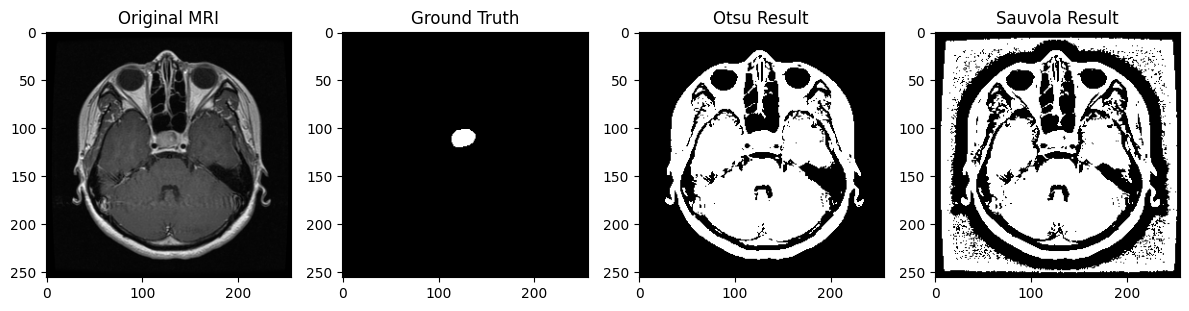

In [7]:
plt.figure(figsize=(12,5))

plt.subplot(1,4,1)
plt.imshow(image, cmap='gray')
plt.title("Original MRI")

plt.subplot(1,4,2)
plt.imshow(mask, cmap='gray')
plt.title("Ground Truth")

plt.subplot(1,4,3)
plt.imshow(otsu_pred, cmap='gray')
plt.title("Otsu Result")

plt.subplot(1,4,4)
plt.imshow(sauvola_pred, cmap='gray')
plt.title("Sauvola Result")

plt.tight_layout()
plt.show()